<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

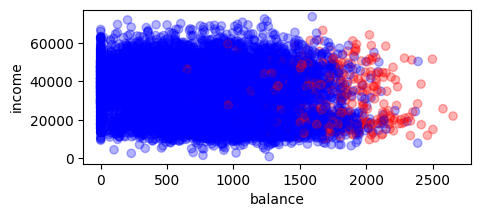

In [ ]:
## logistic regression 을 이용한
## 파산 확률 예측 모형

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Default.csv')
df.head()

# 간단한 전처리
df['default'] = df['default'].astype(str)

# 파산 시각화
colors = {'Yes':'red', 'No':'blue'}
plt.figure(figsize=(5, 2))
plt.scatter(df['balance'], df['income'],
            c=df['default'].apply(lambda x: colors[x]),
            alpha=0.3)
plt.xlabel('balance')
plt.ylabel('income')
plt.show()

In [ ]:
# logit model(logistic regression)
import statsmodels.formula.api as smf

df['default'] = df['default'].map({'Yes':1, 'No':0})
df.head()

,default,student,balance,income
0,0,No,729.526495,44361.625074
1,0,Yes,817.180407,12106.134700
2,0,No,1073.549164,31767.138947
3,0,No,529.250605,35704.493935
4,0,No,785.655883,38463.495879


In [ ]:
model = smf.logit(formula='default ~ balance + income', data = df)
results = model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Wed, 20 May 2026   Pseudo R-squ.:                  0.4594
Time:                        07:37:22   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0

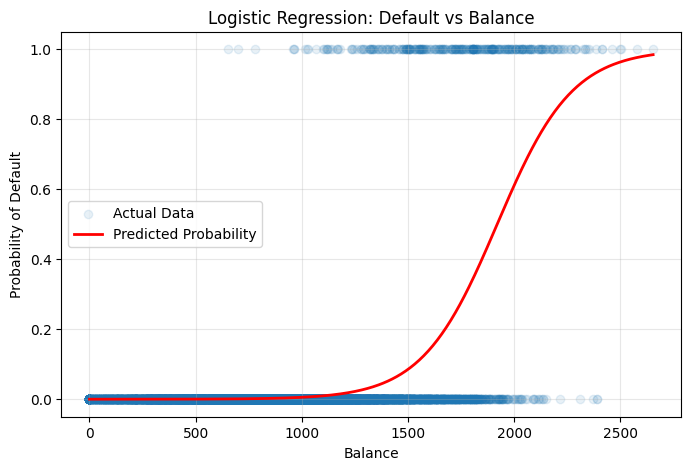

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 산포도 그리기
plt.figure(figsize=(8, 5))
plt.scatter(df['balance'], df['default'], alpha=0.1, label='Actual Data')

# 2. 예측 확률 곡선을 위한 데이터 생성
# income은 평균값으로 고정하고 balance 변화에 따른 확률 계산
X_test = pd.DataFrame({
    'balance': np.linspace(df['balance'].min(), df['balance'].max(), 500),
    'income': df['income'].mean()
})
y_prob = results.predict(X_test)

# 3. 확률 곡선 그리기
plt.plot(X_test['balance'], y_prob, color='red', lw=2, label='Predicted Probability')

plt.xlabel('Balance')
plt.ylabel('Probability of Default')
plt.title('Logistic Regression: Default vs Balance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

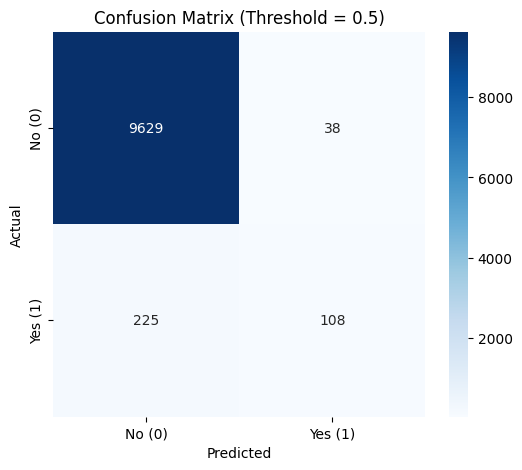

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. 전체 데이터에 대해 확률 예측
df['prob'] = results.predict(df)

# 2. 0.5를 기준으로 분류 (1: Yes, 0: No)
df['pred'] = (df['prob'] > 0.5).astype(int)

# 3. 혼동 행렬 생성
cm = confusion_matrix(df['default'], df['pred'])

# 4. 히트맵 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

In [ ]:
## mnist 데이터를 이용해서
## 손으로 쓴 숫자를 분류기를 훈련
## 0-9까지 있는 숫자 중에서
## 0, 1만 골라내서, 0인지 1인지 분류하는 분류기
## logistic regression 을 이용

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# MNIST 데이터셋 로드
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

In [ ]:
## 필요한 데이터 추출
X, y = mnist.data, mnist.target.astype(int)

z_0_index = np.where( (y==0) | (y==1))
X_01 = X[z_0_index]
y_01 = y[z_0_index]


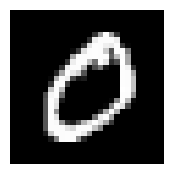

In [ ]:
# visualization
plt.figure(figsize=(3, 2))

plt.imshow(X_01[0].reshape(28, 28), cmap='gray')
# plt.title(f'Label: {y_01[0]}')
plt.axis('off')
plt.show()

In [ ]:
## train/test data split
X_train_01, X_test_01, y_train_01, y_test_01 = train_test_split(X_01, y_01,
                                                                test_size=0.2,
                                                                random_state=0)




In [ ]:
## logist regression model

lm = LogisticRegression()
lm.fit(X_train_01, y_train_01)

y_pred_01 = lm.predict(X_test_01)

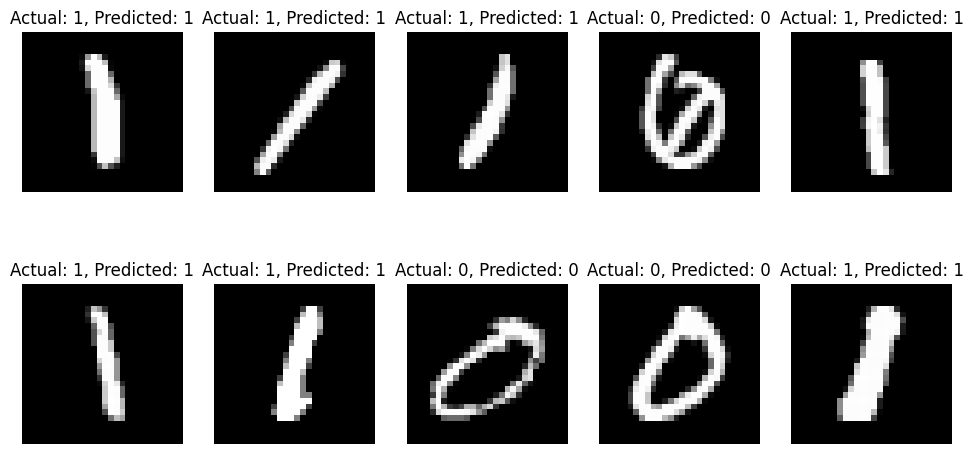

In [ ]:
# 예측된 분류의 정확도를 시각적으로 확인

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_01[i].reshape(28, 28), cmap='gray')
    plt.title(f'Actual: {y_test_01[i]}, Predicted: {y_pred_01[i]}')
    plt.axis('off')

plt.show()